# Chapter 11 Model Selection & Forecasting Strategy
1. Import Libraries
 We start by importing essential Python libraries for numerical computing, data handling, visualization, and modeling.

## ARIMA

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Real financial data
data = yf.download("SPY", start="2018-01-01", end="2024-01-01")
series = data["Close"]

# ARIMA model
model = ARIMA(series, order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)



[*********************100%***********************]  1 of 1 completed
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmode

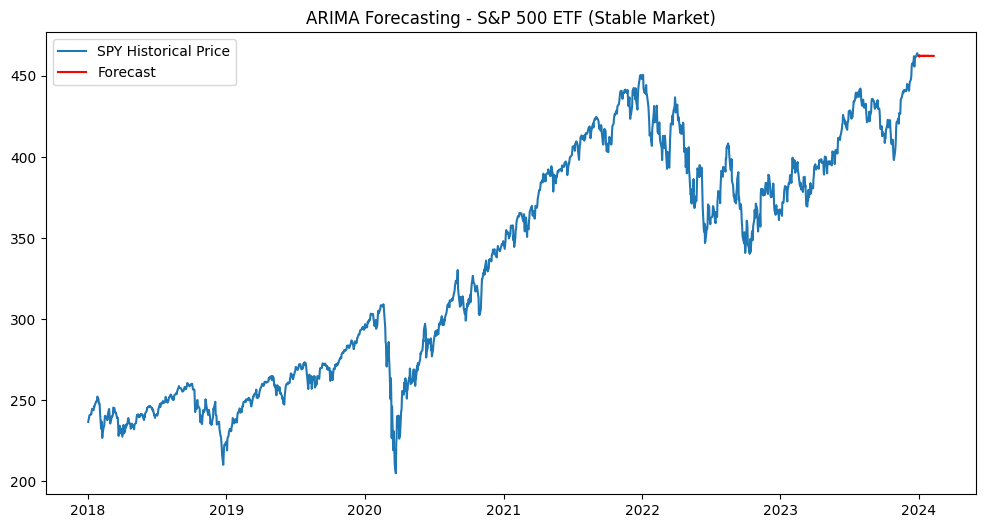

In [ ]:
# -----------------------------
# FIX: Create proper future dates
# -----------------------------
future_dates = pd.date_range(
    start=series.index[-1],
    periods=31,  # include last + 30 future days
    freq="B"     # business days (important for stock data)
)[1:]

# Convert forecast to Series with dates
forecast_series = pd.Series(forecast.values, index=future_dates)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(series, label="SPY Historical Price")
plt.plot(forecast_series, label="Forecast", color="red")

plt.title("ARIMA Forecasting - S&P 500 ETF (Stable Market)")
plt.legend()
plt.show()

## Machine Learning

In [3]:
import yfinance as yf
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Real stock data
df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")

# Feature engineering
df["Return"] = df["Close"].pct_change()
df["MA7"] = df["Close"].rolling(7).mean()
df["MA21"] = df["Close"].rolling(21).mean()
df["Volume_Change"] = df["Volume"].pct_change()

df = df.dropna()

X = df[["Return", "MA7", "MA21", "Volume_Change"]]
y = df["Close"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor()
model.fit(X_train, y_train)

print("ML Model Score:", model.score(X_test, y_test))

/tmp/ipykernel_4351/2817365649.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


ML Model Score: 0.6286406739834367


## Deep Learning

In [5]:
import yfinance as yf
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------
# Load data safely
# -----------------------------
df = yf.download("BTC-USD", start="2020-01-01", auto_adjust=False)

# Always explicitly select Close
data = df["Close"].dropna()

# -----------------------------
# Normalize
# -----------------------------
data = (data - data.mean()) / data.std()

# -----------------------------
# Create sequences safely
# -----------------------------
X, y = [], []

for i in range(10, len(data)):
    X.append(data.iloc[i-10:i].values)   # FIX: use iloc
    y.append(data.iloc[i])

X = np.array(X).reshape(-1, 10, 1)
y = np.array(y)

# -----------------------------
# LSTM model
# -----------------------------
model = Sequential([
    LSTM(50, input_shape=(10,1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X, y, epochs=3, batch_size=32)

[*********************100%***********************]  1 of 1 completed


Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1285
Epoch 2/3
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0114
Epoch 3/3
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0079


## Model Selection Logic

In [6]:
import yfinance as yf
import numpy as np

# Get real financial data (example: SPY index)
data = yf.download("SPY", start="2015-01-01", end="2024-01-01")
data = data["Close"].dropna()

# Feature: dataset properties
data_size = len(data)

# Simple heuristic for structure (proxy for linearity)
returns = data.pct_change().dropna()
linearity = abs(returns.mean()) < 0.001  # low drift → more linear/stable

# -------------------------------
# Model Selection Engine
# -------------------------------
def choose_model(data_size, linearity):
    if data_size < 500 and linearity:
        return "ARIMA (Stable Market Forecasting)"
    elif data_size < 5000:
        return "Machine Learning (Feature-Based Trading Model)"
    else:
        return "Deep Learning (High-Frequency / Complex Market Model)"

# Decision
model = choose_model(data_size, linearity)

print("Dataset Size:", data_size)
print("Market Linearity:", linearity)
print("Selected Model:", model)

/tmp/ipykernel_4351/3277139986.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Dataset Size: 2264
Market Linearity: Ticker
SPY    True
dtype: bool
Selected Model: Machine Learning (Feature-Based Trading Model)
